In [1]:
import scipy.io as sio

data = sio.loadmat("data/FLIC-full/examples.mat")

print(data.keys())

examples = data["examples"]

dict_keys(['__header__', '__version__', '__globals__', 'examples'])


In [2]:
import numpy as np

dataset = []

num_samples = examples.shape[1]

for i in range(num_samples):
    ex = examples[0, i]

    filepath = ex['filepath'][0]

    coords = np.squeeze(ex['coords'])   # (2, 29)
    keypoints = coords.T                # (29, 2)

    dataset.append((filepath, keypoints))

In [4]:
import os
from tensorflow.keras.preprocessing import image
import numpy as np

image_size = (128, 128)
num_joints = 29

images_folder = "data/FLIC-full/images"

def load_image_and_keypoints(filename, keypoints, folder=images_folder):
    filepath = os.path.join(folder, filename)
    
    if not os.path.exists(filepath):
        raise FileNotFoundError(f"File does not exist: {filepath}")
    
    img = image.load_img(filepath, target_size=image_size)
    img_array = image.img_to_array(img)

    # Handle missing keypoints
    keypoints = np.nan_to_num(keypoints, nan=0.0)

    # Normalize coordinates to [0,1]
    # keypoints[:, 0] /= image_size[1]  # x / width
    # keypoints[:, 1] /= image_size[0]  # y / height
    
    return img_array, keypoints

In [5]:
import numpy as np
from tqdm import tqdm
from sklearn.model_selection import train_test_split

X = []
y = []
filenames_list = []

for filename, keypoints in tqdm(dataset, desc="Processing Images"):
    img_array, keypoints_norm = load_image_and_keypoints(filename, keypoints, folder=images_folder)
    X.append(img_array)
    y.append(keypoints_norm)
    filenames_list.append(filename) # Store the name

X = np.array(X, dtype=np.float32)
y = np.array(y, dtype=np.float32)
filenames_list = np.array(filenames_list) # Convert to array for easy indexing

# Split the filenames alongside X and y
X_train, X_test, y_train, y_test, filenames_train, filenames_test = train_test_split(
    X, y, filenames_list, test_size=0.2, random_state=42
)

print(f"Total samples: {len(X)}")
print(f"Training set: {X_train.shape[0]}")
print(f"Testing set: {X_test.shape[0]}")

Processing Images: 100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 20928/20928 [03:08<00:00, 111.17it/s]


Total samples: 20928
Training set: 16742
Testing set: 4186


In [6]:
import tensorflow as tf

# Load saved model
model = tf.keras.models.load_model("model.keras")

print("Model loaded successfully")

# model.summary()

print(X_train)

# Run inference
predictions = model.predict(X_test)



Model loaded successfully
[[[[153. 153. 153.]
   [159. 159. 159.]
   [162. 162. 162.]
   ...
   [173. 173. 173.]
   [171. 171. 171.]
   [161. 161. 161.]]

  [[153. 153. 153.]
   [160. 160. 160.]
   [160. 160. 160.]
   ...
   [176. 176. 176.]
   [178. 178. 178.]
   [170. 170. 170.]]

  [[151. 151. 151.]
   [154. 154. 154.]
   [155. 155. 155.]
   ...
   [172. 172. 172.]
   [182. 182. 182.]
   [171. 171. 171.]]

  ...

  [[125. 125. 125.]
   [129. 129. 129.]
   [105. 105. 105.]
   ...
   [  9.   9.   9.]
   [ 11.  11.  11.]
   [ 16.  16.  16.]]

  [[ 77.  77.  77.]
   [ 99.  99.  99.]
   [122. 122. 122.]
   ...
   [  9.   9.   9.]
   [  9.   9.   9.]
   [ 22.  22.  22.]]

  [[119. 119. 119.]
   [133. 133. 133.]
   [115. 115. 115.]
   ...
   [  9.   9.   9.]
   [  7.   7.   7.]
   [ 21.  21.  21.]]]


 [[[  2.   2.   2.]
   [  0.   0.   0.]
   [  0.   0.   0.]
   ...
   [  3.   3.   3.]
   [  0.   0.   0.]
   [  1.   1.   1.]]

  [[  1.   1.   1.]
   [  0.   0.   0.]
   [  0.   0.   0.]
  

In [11]:
import matplotlib.pyplot as plt
import cv2
import numpy as np

def visualize_predictions(images, true_pts, pred_pts, filenames, num_images=5):
    # Determine how many images to actually show (don't exceed what we have)
    num_to_show = min(len(images), num_images)
    
    plt.figure(figsize=(12, 6 * num_to_show))
    
    for i in range(num_to_show):
        # 1. Prepare the Image
        img = images[i].copy()
        
        # Scale back to 0-255 if it's 0-1
        if img.max() <= 1.0:
            img = (img * 255).astype(np.uint8)
        
        # OpenCV uses BGR, Matplotlib uses RGB. This is CRUCIAL for the image to show.
        img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        
        h, w, _ = img_rgb.shape
        
        # 2. Reshape and Scale Points
        # Predictions and True points are (29, 2) in normalized [0, 1] range
        current_true = true_pts[i].reshape(-1, 2)
        current_pred = pred_pts[i].reshape(-1, 2)
        
        # Create subplot
        ax = plt.subplot(num_to_show, 1, i + 1)
        ax.imshow(img_rgb)
        
        # 3. Overlay Points
        # x = coord[:, 0] * width | y = coord[:, 1] * height
        ax.scatter(current_true[:, 0] * w, current_true[:, 1] * h, 
                   c='lime', s=40, edgecolors='black', label='Ground Truth', zorder=3)
        
        ax.scatter(current_pred[:, 0] * w, current_pred[:, 1] * h, 
                   c='red', s=45, marker='x', label='Predicted', zorder=4)
        
        ax.set_title(f"File: {filenames[i]}")
        ax.legend(loc='upper right')
        ax.axis('off') # Hide axes for a cleaner look

    plt.tight_layout()
    plt.show()



Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.0..255.0].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.0..255.0].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.0..242.0].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.0..255.0].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.0..255.0].


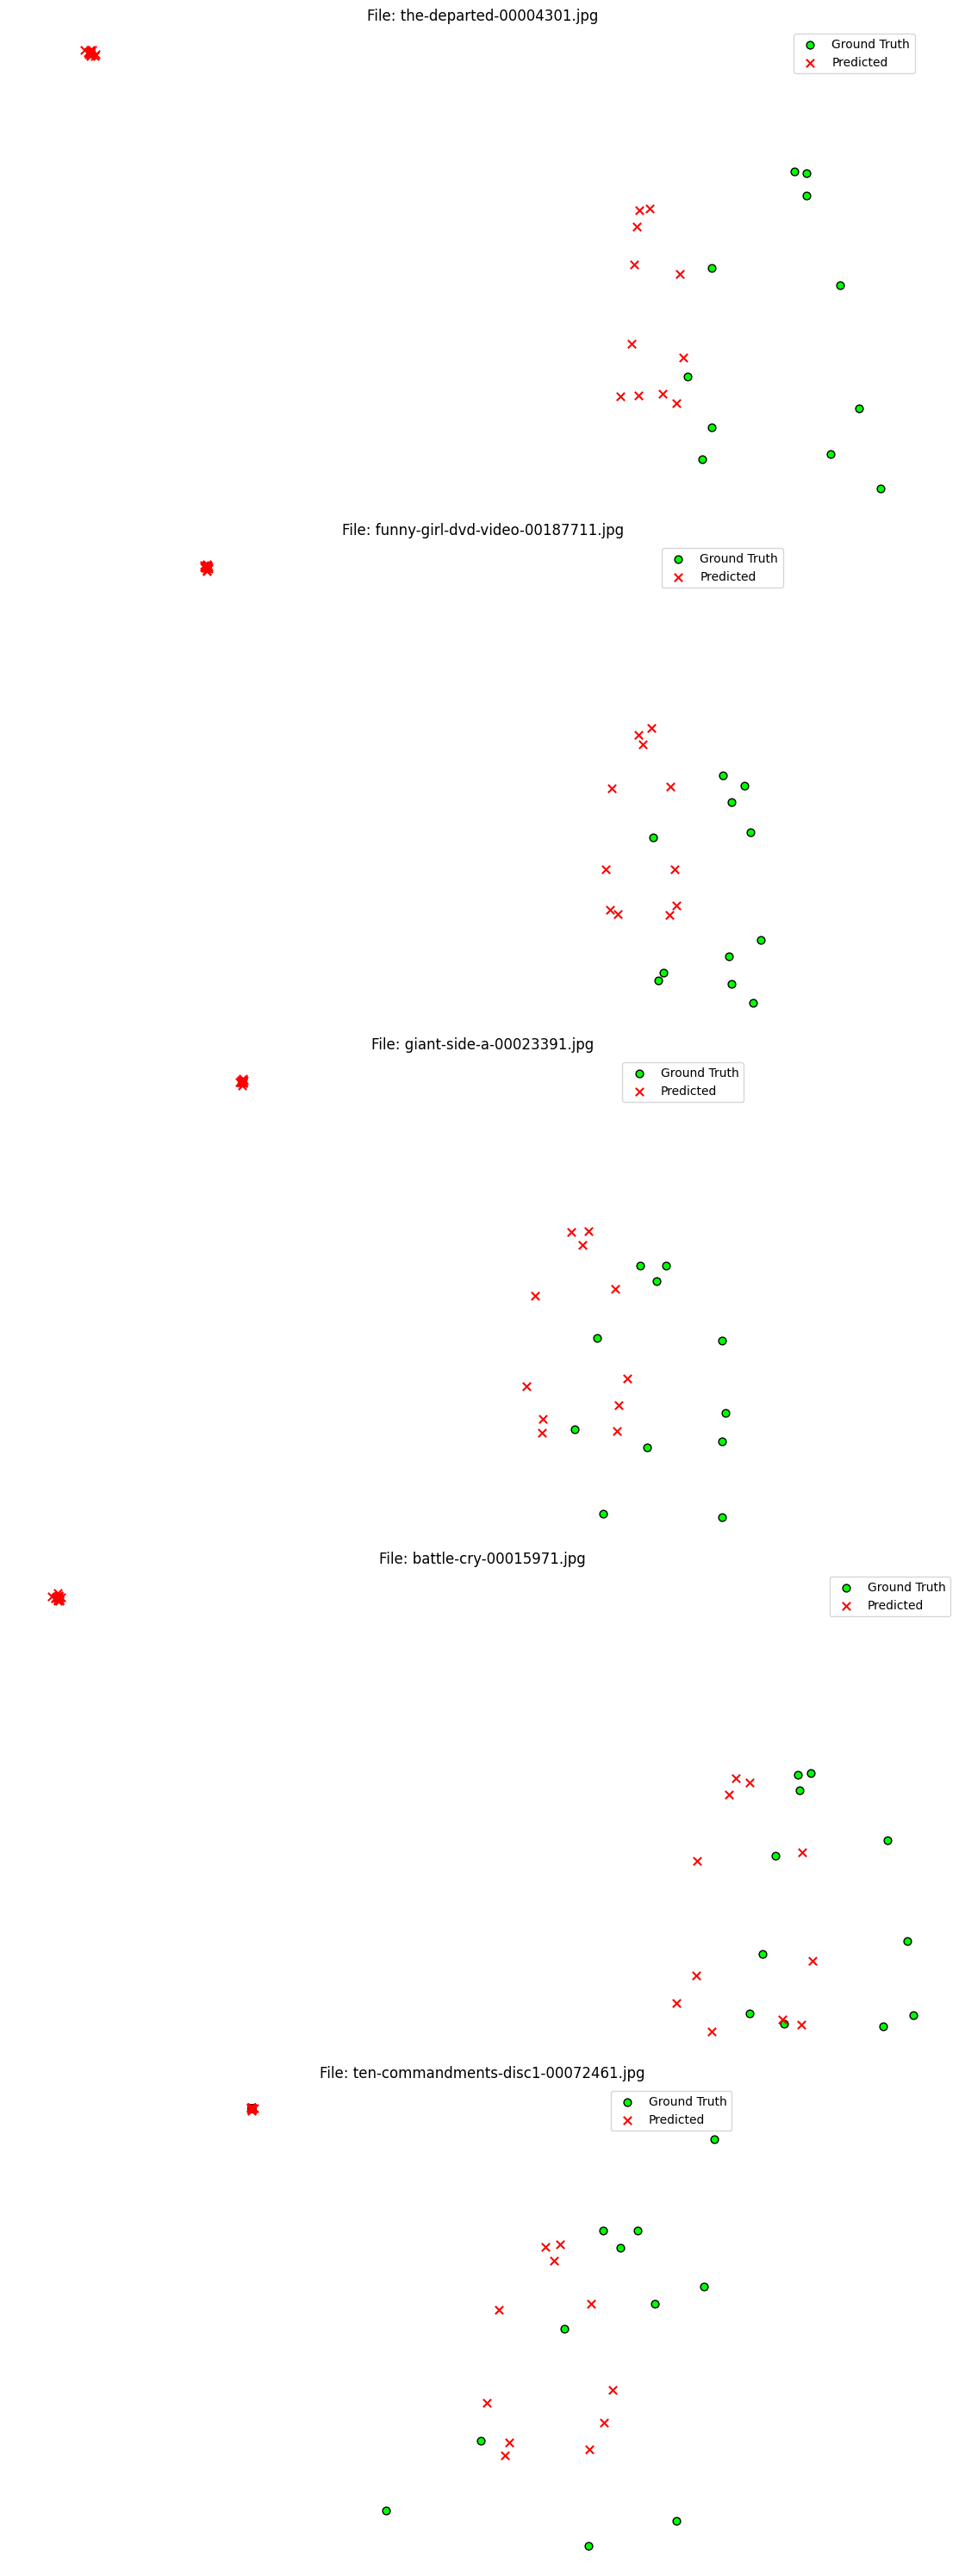

In [12]:
# Call the function
visualize_predictions(X_test, y_test, predictions, filenames_test, num_images=5)

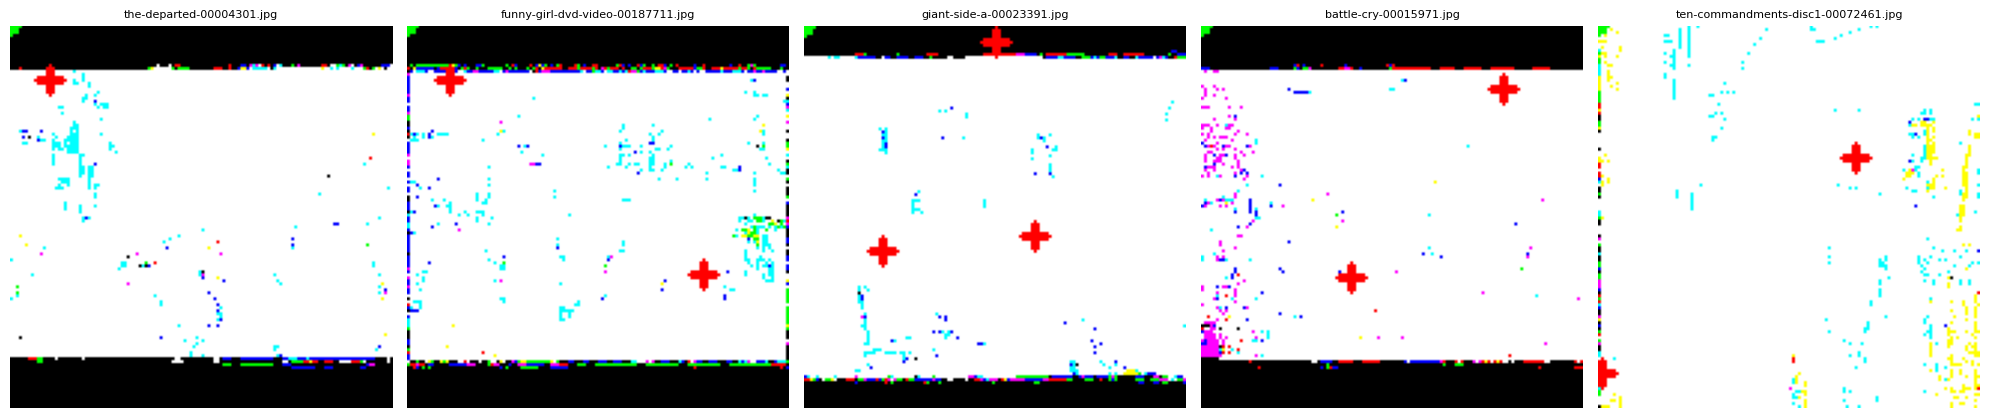

In [17]:
import matplotlib.pyplot as plt
import cv2
import numpy as np

def plot_test_results(X_test, y_test, predictions, filenames_test, num_to_show=5):
    plt.figure(figsize=(20, 10))
    
    for i in range(num_to_show):
        # 1. CLEAN IMAGE CONVERSION
        img = X_test[i].copy()
        
        # If image is float (0 to 1), scale it. 
        # clip(0, 1) prevents the "wrap-around" overflow errors
        if img.dtype != np.uint8:
            img = np.clip(img, 0, 1) * 255
            img = img.astype(np.uint8)
        
        # Matplotlib uses RGB, OpenCV uses BGR. 
        # If your images look "blueish" or "weird", swap this:
        img_display = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        
        h, w, _ = img_display.shape
        
        # 2. COORDINATE SCALING
        # Ensure coordinates are scaled by the ACTUAL current image width/height
        true_pts = y_test[i].reshape(-1, 2)
        pred_pts = predictions[i].reshape(-1, 2)

        # Draw Ground Truth (Green Circles)
        for pt in true_pts:
            tx, ty = int(pt[0] * w), int(pt[1] * h)
            if 0 <= tx < w and 0 <= ty < h:
                cv2.circle(img_display, (tx, ty), 3, (0, 255, 0), -1)

        # Draw Predictions (Red Crosses)
        for pt in pred_pts:
            px, py = int(pt[0] * w), int(pt[1] * h)
            if 0 <= px < w and 0 <= py < h:
                cv2.drawMarker(img_display, (px, py), (255, 0, 0), 
                               markerType=cv2.MARKER_CROSS, markerSize=8, thickness=2)

        # 3. PLOT
        plt.subplot(1, num_to_show, i + 1)
        plt.imshow(img_display)
        plt.title(f"{filenames_test[i]}", fontsize=8)
        plt.axis("off")

    plt.tight_layout()
    plt.show()

plot_test_results(X_test, y_test, predictions, filenames_test, num_to_show=5)

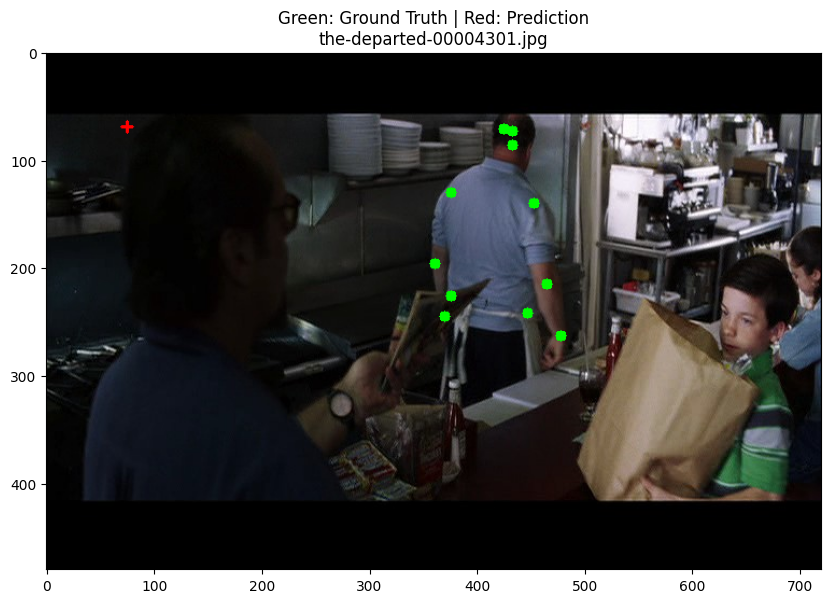

In [29]:
# 1. Load Image
fp = filenames_test[0]
img_path = os.path.join("data", "FLIC-full", "images", fp)
img = cv2.imread(img_path)
img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
h, w, _ = img.shape

# 2. Ground Truth (Green) - Already in pixels
gt_coords = y_test[0] 
for i in range(len(gt_coords)):
    x, y = gt_coords[i]
    if x > 0 and y > 0:
        cv2.circle(img, (int(x), int(y)), 5, (0, 255, 0), -1)

# 3. Predictions (Red) - Normalized, so we scale them
pred_coords = predictions[0].reshape(-1, 2)
for i in range(len(pred_coords)):
    # Scale normalized prediction back to image pixel size
    px = int(pred_coords[i][0] * w) 
    py = int(pred_coords[i][1] * h)
    
    cv2.drawMarker(img, (px, py), (255, 0, 0), cv2.MARKER_CROSS, 10, 2)

plt.figure(figsize=(10,10))
plt.imshow(img)
plt.title(f"Green: Ground Truth | Red: Prediction\n{fp}")
plt.show()

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 989ms/step


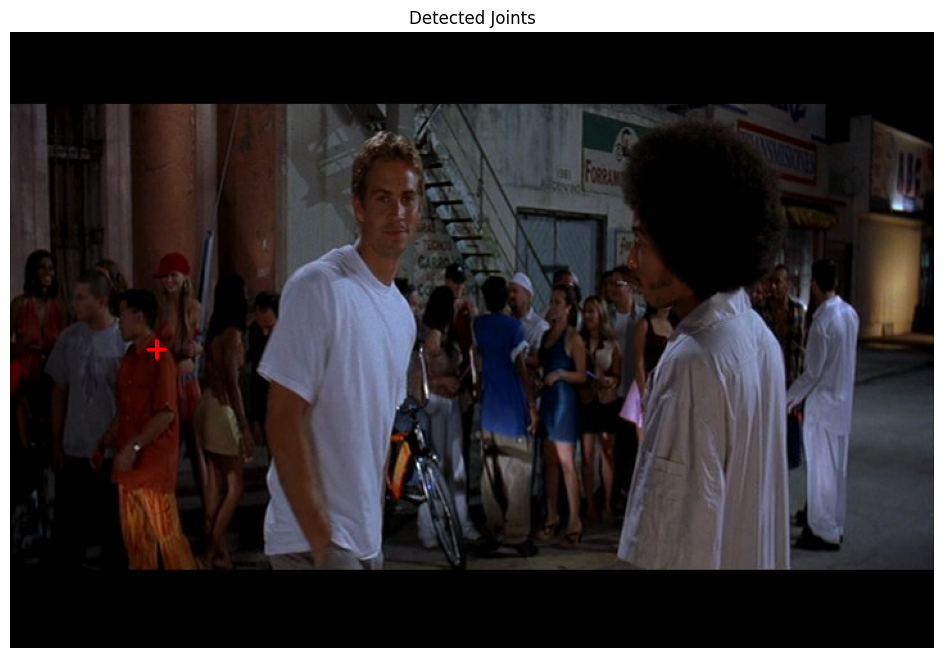

In [31]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

def detect_joints_on_new_image(image_path, model):
    # 1. Load the original image
    original_img = cv2.imread(image_path)
    if original_img is None:
        print("Error: Could not load image.")
        return
    
    orig_h, orig_w = original_img.shape[:2]
    img_display = cv2.cvtColor(original_img, cv2.COLOR_BGR2RGB)

    # 2. Preprocess for the model (128x128)
    input_size = (128, 128)
    resized_img = cv2.resize(original_img, input_size)
    normalized_img = resized_img.astype(np.float32) / 255.0
    input_batch = np.expand_dims(normalized_img, axis=0) # Make it (1, 128, 128, 3)

    # 3. Run Inference
    preds = model.predict(input_batch)[0] # Get the first (and only) prediction
    preds = preds.reshape(-1, 2) # Shape (29, 2)

    # 4. Map points back to original image size and Draw
    for i in range(len(preds)):
        # Important: Multiply normalized (0-1) by original dimensions
        px = int(preds[i][0] * orig_w)
        py = int(preds[i][1] * orig_h)
        
        # Draw on the original high-res image
        cv2.drawMarker(img_display, (px, py), (255, 0, 0), 
                       markerType=cv2.MARKER_CROSS, markerSize=15, thickness=2)

    # 5. Show results
    plt.figure(figsize=(12, 8))
    plt.imshow(img_display)
    plt.title("Detected Joints")
    plt.axis('off')
    plt.show()

img_path = os.path.join("data", "FLIC-full", "images", "2-fast-2-furious-00008001.jpg")
# Run it on your file
detect_joints_on_new_image(img_path, model)